In [ ]:
!pip install transformers accelerate datasets nltk evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

raw_dataset = load_dataset("jxie/flickr8k")
print(raw_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [ ]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [ ]:
# Apply Lora
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["qkv"],
    lora_dropout=0.1,
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 589,824 || all params: 248,034,424 || trainable%: 0.2378


In [ ]:
def preprocess(example):
    image = example["image"]
    caption = example["caption_0"]  # or random

    inputs = processor(
        images=image,
        text=caption,
        padding="max_length",
        truncation=True,
        max_length=30,
        return_tensors="pt"
    )

    return {
        "pixel_values": inputs["pixel_values"].squeeze(0),
        "input_ids": inputs["input_ids"].squeeze(0),
        "attention_mask": inputs["attention_mask"].squeeze(0)
    }

processed_dataset = raw_dataset.map(
    preprocess,
    remove_columns=raw_dataset["train"].column_names
)

processed_dataset.set_format(type="torch")

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
import torch
import torch.nn as nn
from transformers import BlipForConditionalGeneration
from peft import get_peft_model, LoraConfig

class ImageCaptionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = BlipForConditionalGeneration.from_pretrained(
            "Salesforce/blip-image-captioning-base"
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        outputs = self.model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids   # 🔥 IMPORTANT for training
        )
        return outputs

In [ ]:
# Data Loader
from torch.utils.data import DataLoader

def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
    }

train_loader = DataLoader(
    processed_dataset["train"],
    batch_size=4,
    shuffle=True,
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImageCaptionModel().to(device)

from torch.optim import AdamW
from tqdm import tqdm
import torch

# Train only LoRA params
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5
)

# Mixed precision
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(pixel_values, input_ids, attention_mask)
            loss = outputs.loss

        # Backward with scaler
        scaler.scale(loss).backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Epoch 1, Loss: 2059.8797


100%|██████████| 1500/1500 [11:02<00:00,  2.26it/s]


Epoch 2, Loss: 1049.4811


...

Epoch 6, Loss: 292.2060


100%|██████████| 1500/1500 [11:14<00:00,  2.22it/s]


Epoch 7, Loss: 213.4081


100%|██████████| 1500/1500 [11:15<00:00,  2.22it/s]

Epoch 8, Loss: 138.8609


In [ ]:
def generate_caption(image):
    model.eval()

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = model.model.generate(
            pixel_values=inputs["pixel_values"],
            max_length=30,
            num_beams=5,              # 🔥 beam search
            no_repeat_ngram_size=2,
            repetition_penalty=1.2,
            early_stopping=True
        )

    caption = processor.tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption.strip()

In [ ]:
import evaluate
from tqdm import tqdm

bleu = evaluate.load("bleu")

predictions = []
references = []

model.eval()

for sample in tqdm(raw_dataset['test']):

    # Generate caption using BLIP
    pred = generate_caption(sample['image'])

    # Ensure prediction is string
    predictions.append(pred.strip())

    # References MUST be list of list of strings
    refs = [
        sample["caption_0"],
        sample["caption_1"],
        sample["caption_2"],
        sample["caption_3"],
        sample["caption_4"]
    ]

    # clean references
    refs = [r.strip() for r in refs]

    references.append(refs)

# Compute BLEU
results = bleu.compute(
    predictions=predictions,
    references=references
)

print("BLEU Score:", results)


100%|██████████| 1000/1000 [06:57<00:00,  2.40it/s]


BLEU Score: {'bleu': 0.24646863836118996, 'precisions': [0.6923076923076923, 0.3511325301204819, 0.17706666666666668, 0.08573134328358209], 'brevity_penalty': 1.0, 'length_ratio': 1.4140974639482844, 'translation_length': 11375, 'reference_length': 8044}


NotImplementedError: Could not run 'quantized::linear_dynamic' with arguments from the 'CUDA' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::linear_dynamic' is only available for these backends: [CPU, Meta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, PythonTLSSnapshot, FuncTorchDynamicLayerFrontMode, PreDispatch,

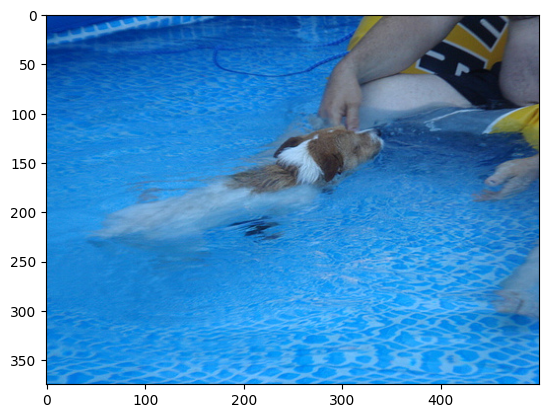

In [ ]:
import matplotlib.pyplot as plt

sample = raw_dataset['test'][1]

plt.imshow(sample['image'])
plt.title(generate_caption(sample['image']))
plt.axis('off')

In [ ]:
SAVE_PATH = "/content/image_caption_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
}, SAVE_PATH)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
SAVE_PATH = "/content/image_caption_checkpoint.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": EPOCHS,
}, SAVE_PATH)

print("Full checkpoint saved!")

Full checkpoint saved!


In [ ]:
!pip install peft -q

In [ ]:
# Adding LORA to GPT2 and adding beam search